### Coding Question: Image Classification Neural Network

Using the dataset provided below, design and implement a **Neural Network for multi-class image classification**.

**Dataset:** [Nepali Numbers and Letters Dataset](https://github.com/ShaileshAdhikari/nepali-text-classification/blob/main/images.rar)

Your implementation should include:

1. **Data Preparation**

   * Load, preprocess, resize, normalize, and split the dataset into train/validation/test sets.

2. **Neural Network**

3. **Hyperparameter Tuning**

4. **Evaluation**
   Evaluate the final model using:

   * Accuracy
   * Precision
   * Recall
   * F1-score
   * Macro/Weighted F1
   * Confusion Matrix

5. **Performance Analysis**

**Deliverable:** Complete, reproducible code with a final report comparing the experimented configurations and their performance.


___
___
# Solution

___

DATASET CLASSES
0: 0
1: 1
2: 2
3: 3
4: 4
5: 5
6: 6
7: 7
8: 8
9: 9
10: ba
11: pa

DATASET INFORMATION
Total images: 2033
Number of classes: 12
Class names: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'ba', 'pa']

CLASS DISTRIBUTION
label
0      96
1     171
2     176
3     186
4     206
5     194
6     159
7     147
8     135
9     123
ba    206
pa    234
Name: count, dtype: int64

DATA SPLIT
Training images   : 1423
Validation images : 305
Testing images    : 305

Loading training images...
Loading validation images...
Loading test images...

IMAGE SHAPES
Training   : (1423, 64, 64, 1)
Validation : (305, 64, 64, 1)
Testing    : (305, 64, 64, 1)

Pixel statistics:
Minimum: 0.003921569
Maximum: 1.0
Mean   : 0.56004


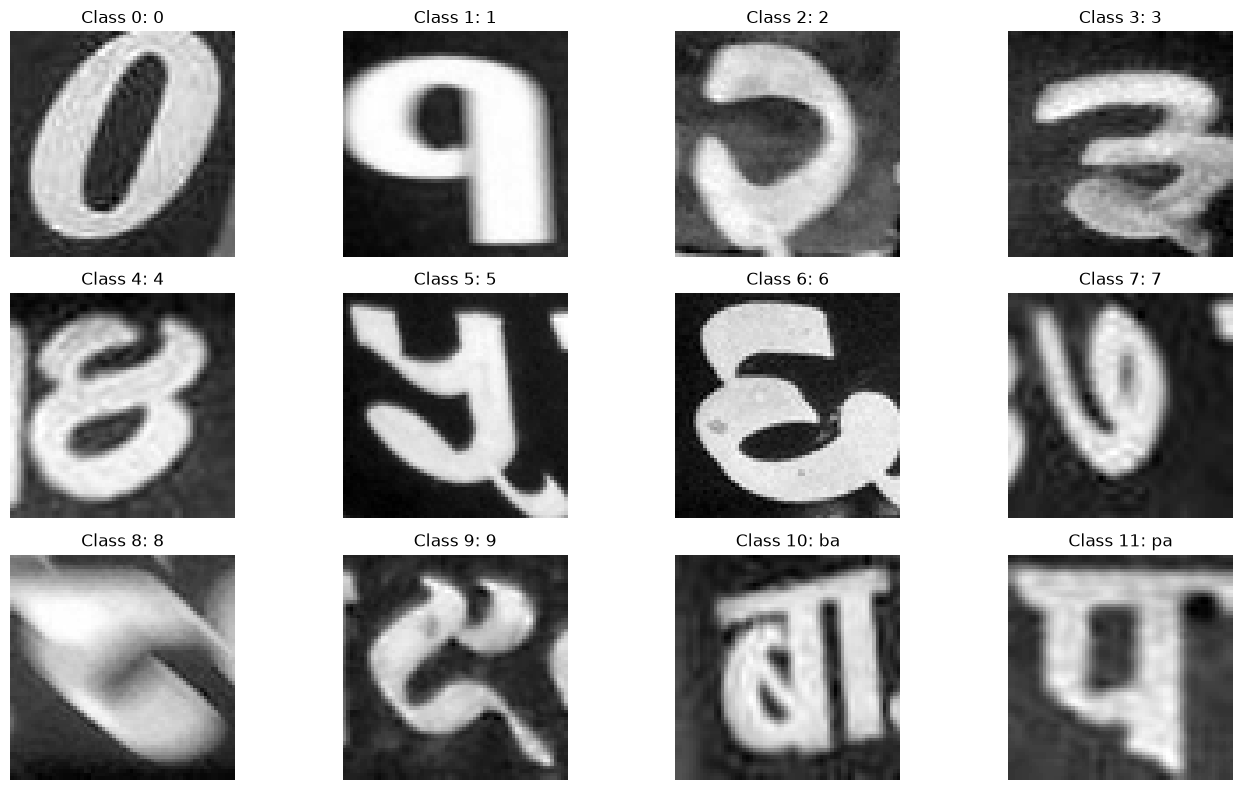


CLASS WEIGHTS
    0: 1.7699
    1: 0.9882
    2: 0.9641
    3: 0.9122
    4: 0.8235
    5: 0.8719
    6: 1.0683
    7: 1.1513
    8: 1.2482
    9: 1.3789
   ba: 0.8235
   pa: 0.7231

PREVIOUS BASELINE
Test Accuracy : 0.3377
Test Macro F1 : 0.2754

TRAINING EXPERIMENT: Deeper_CNN
Parameters:
{'filters': (32, 64, 128), 'dense_units': 256, 'dropout': 0.4, 'learning_rate': 0.001, 'batch_size': 32}
Epoch 1/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 26s 481ms/step - accuracy: 0.1047 - loss: 3.9825 - val_accuracy: 0.1213 - val_loss: 2.4743 - learning_rate: 0.0010
Epoch 2/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 41s 482ms/step - accuracy: 0.1075 - loss: 2.4559 - val_accuracy: 0.1377 - val_loss: 2.4632 - learning_rate: 0.0010
Epoch 3/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 47s 617ms/step - accuracy: 0.1356 - loss: 2.4091 - val_accuracy: 0.1213 - val_loss: 2.4495 - learning_rate: 0.0010
Epoch 4/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 18s 391ms/step - accuracy: 0.1560 - loss: 2.3666 - val_accuracy: 0.1836 - val_loss: 2.4037 - learning_rat

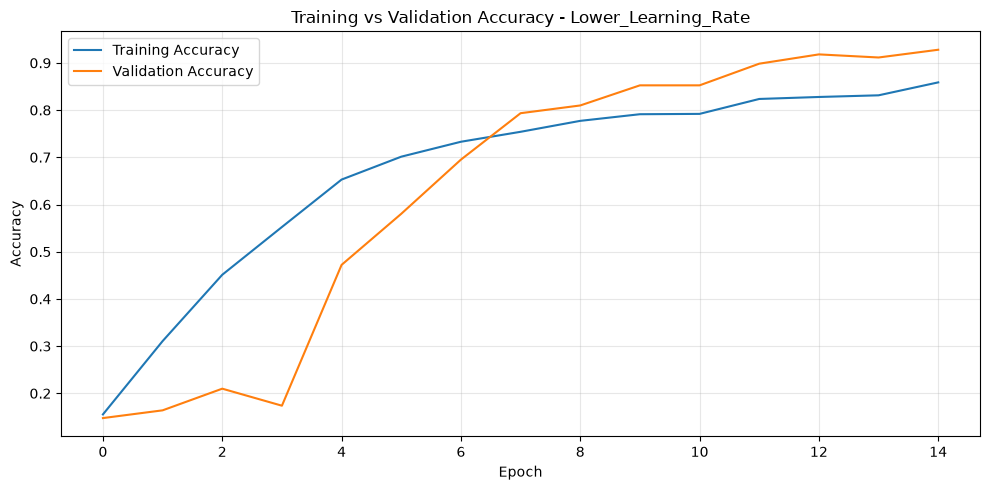

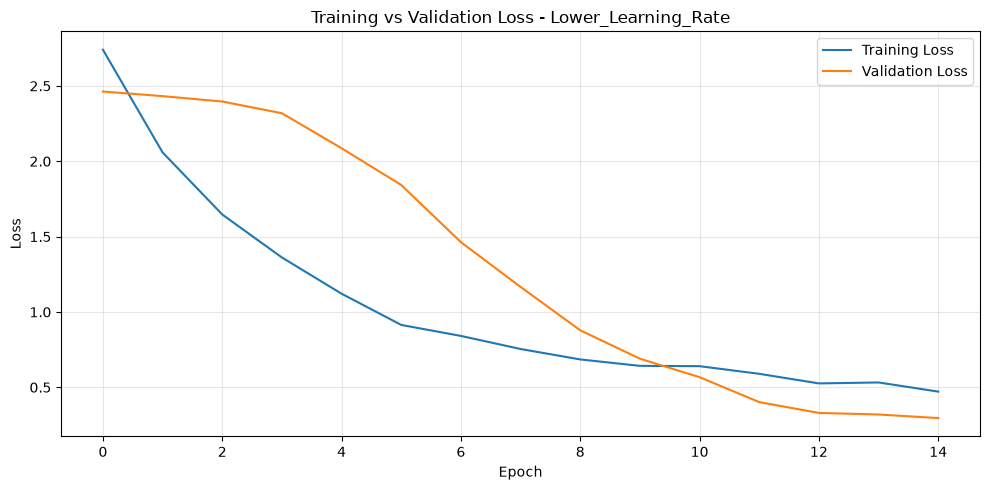


FINAL TEST EVALUATION
Test Loss       : 0.3288
Accuracy        : 0.9082
Macro Precision : 0.9248
Macro Recall    : 0.9101
Macro F1        : 0.9119
Weighted F1     : 0.9099

FINAL CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.93      0.93      0.93        15
           1       1.00      0.88      0.94        25
           2       0.96      0.96      0.96        27
           3       0.96      0.93      0.95        28
           4       0.92      0.71      0.80        31
           5       0.97      0.97      0.97        29
           6       0.95      0.83      0.89        24
           7       0.68      0.95      0.79        22
           8       1.00      0.95      0.97        20
           9       1.00      0.89      0.94        18
          ba       0.76      1.00      0.86        31
          pa       0.97      0.91      0.94        35

    accuracy                           0.91       305
   macro avg       0.92      0.91      0

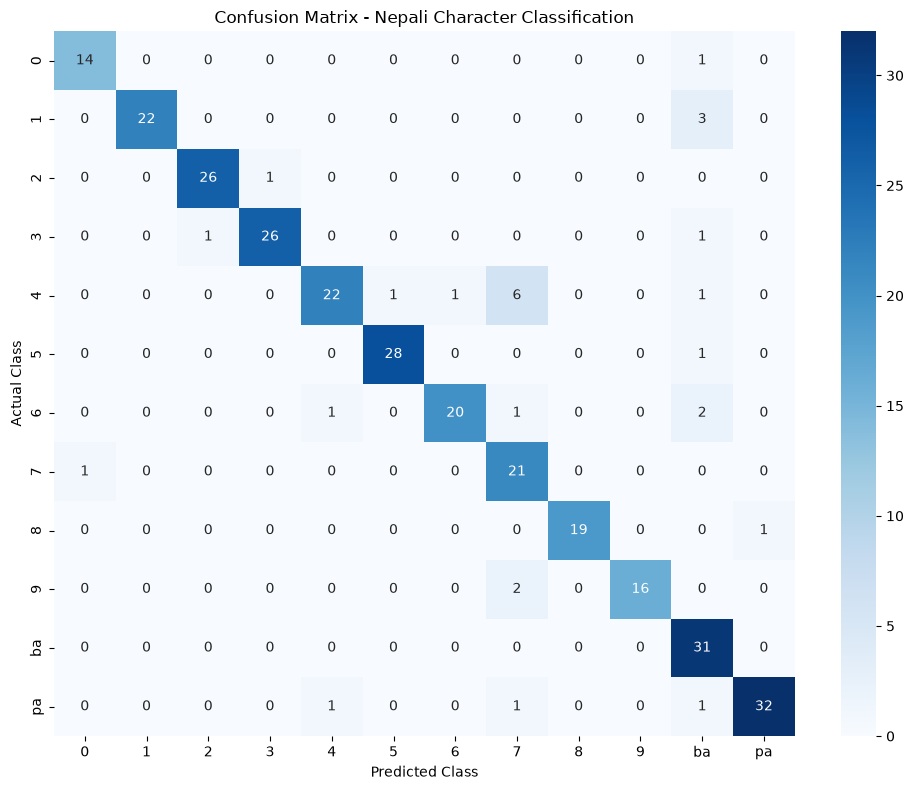


FINAL SUMMARY
         Metric  Final Model
      Test Loss     0.328829
       Accuracy     0.908197
Macro Precision     0.924753
   Macro Recall     0.910093
       Macro F1     0.911884
    Weighted F1     0.909863

DONE
Best model saved as: best_nepali_cnn.keras
Experiment results saved as: experiment_results.csv
Final metrics saved as: final_metrics.csv
Classification report saved as: classification_report.txt
Confusion matrix saved as: confusion_matrix.png


In [27]:
# ============================================================
# Neural Network for Multi-Class Image Classification
# Nepali Numbers and Letters Dataset
#
# Dataset structure:
# images/
#   ├── 0/
#   ├── 1/
#   ├── ...
#   ├── 9/
#   ├── ba/
#   └── pa/
#
# Total classes: 12
# Image size: 64 x 64
# Channels: Grayscale
# Split: 70% train / 15% validation / 15% test
# ============================================================


# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)


# ============================================================
# 2. REPRODUCIBILITY
# ============================================================

SEED = 42

np.random.seed(SEED)
tf.random.set_seed(SEED)


# ============================================================
# 3. CONFIGURATION
# ============================================================

DATASET_DIR = Path("images")

IMAGE_SIZE = (64, 64)

VALID_EXTENSIONS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".tif",
    ".tiff",
    ".webp"
}


# ============================================================
# 4. CHECK DATASET
# ============================================================

if not DATASET_DIR.exists():
    raise FileNotFoundError(
        f"Dataset folder '{DATASET_DIR}' was not found.\n"
        f"Make sure the 'images' folder is in the same directory "
        f"as this Python file."
    )


# ============================================================
# 5. FIND CLASS DIRECTORIES
# ============================================================

class_dirs = sorted(
    [
        directory
        for directory in DATASET_DIR.iterdir()
        if directory.is_dir()
    ],
    key=lambda x: x.name
)

print("=" * 60)
print("DATASET CLASSES")
print("=" * 60)

for i, directory in enumerate(class_dirs):
    print(f"{i}: {directory.name}")


# ============================================================
# 6. LOAD IMAGE PATHS AND LABELS
# ============================================================

records = []

for class_dir in class_dirs:

    class_name = class_dir.name

    for image_path in class_dir.rglob("*"):

        if (
            image_path.is_file()
            and image_path.suffix.lower() in VALID_EXTENSIONS
        ):

            records.append(
                {
                    "path": str(image_path),
                    "label": class_name
                }
            )


df = pd.DataFrame(records)


if len(df) == 0:
    raise RuntimeError(
        "No image files were found inside the dataset folders."
    )


print("\n" + "=" * 60)
print("DATASET INFORMATION")
print("=" * 60)

print(f"Total images: {len(df)}")


# ============================================================
# 7. ENCODE CLASS LABELS
# ============================================================

label_encoder = LabelEncoder()

df["encoded_label"] = label_encoder.fit_transform(
    df["label"]
)

class_names = list(label_encoder.classes_)

num_classes = len(class_names)

print(f"Number of classes: {num_classes}")
print(f"Class names: {class_names}")


# ============================================================
# 8. CLASS DISTRIBUTION
# ============================================================

print("\n" + "=" * 60)
print("CLASS DISTRIBUTION")
print("=" * 60)

class_distribution = (
    df["label"]
    .value_counts()
    .sort_index()
)

print(class_distribution)


# ============================================================
# 9. STRATIFIED TRAIN / VALIDATION / TEST SPLIT
# ============================================================

X = df["path"].values
y = df["encoded_label"].values


# First split:
# 70% training
# 30% temporary

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=SEED
)


# Second split:
# 15% validation
# 15% test

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=SEED
)


print("\n" + "=" * 60)
print("DATA SPLIT")
print("=" * 60)

print(f"Training images   : {len(X_train)}")
print(f"Validation images : {len(X_val)}")
print(f"Testing images    : {len(X_test)}")


# ============================================================
# 10. LOAD AND PREPROCESS IMAGES
# ============================================================

def load_images(paths):

    images = []

    for path in paths:

        image = Image.open(path).convert("L")

        image = image.resize(
            IMAGE_SIZE,
            Image.Resampling.LANCZOS
        )

        image = np.asarray(
            image,
            dtype=np.float32
        )

        # Normalize pixels from [0,255] to [0,1]
        image = image / 255.0

        # Add channel dimension
        # (64,64) -> (64,64,1)
        image = np.expand_dims(
            image,
            axis=-1
        )

        images.append(image)

    return np.array(
        images,
        dtype=np.float32
    )


print("\nLoading training images...")

X_train_img = load_images(X_train)

print("Loading validation images...")

X_val_img = load_images(X_val)

print("Loading test images...")

X_test_img = load_images(X_test)


print("\n" + "=" * 60)
print("IMAGE SHAPES")
print("=" * 60)

print("Training   :", X_train_img.shape)
print("Validation :", X_val_img.shape)
print("Testing    :", X_test_img.shape)

print("\nPixel statistics:")
print("Minimum:", X_train_img.min())
print("Maximum:", X_train_img.max())
print("Mean   :", X_train_img.mean())


# ============================================================
# 11. VISUALIZE SAMPLE IMAGES
# ============================================================

plt.figure(figsize=(14, 8))

for class_id, class_name in enumerate(class_names):

    indices = np.where(
        y_train == class_id
    )[0]

    if len(indices) == 0:
        continue

    index = indices[0]

    plt.subplot(3, 4, class_id + 1)

    plt.imshow(
        X_train_img[index].squeeze(),
        cmap="gray"
    )

    plt.title(
        f"Class {class_id}: {class_name}"
    )

    plt.axis("off")

plt.tight_layout()

plt.savefig(
    "sample_images.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 12. CALCULATE CLASS WEIGHTS
# ============================================================

classes = np.unique(y_train)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weights = {
    int(class_id): float(weight)
    for class_id, weight in zip(
        classes,
        weights
    )
}


print("\n" + "=" * 60)
print("CLASS WEIGHTS")
print("=" * 60)

for class_id, weight in class_weights.items():

    print(
        f"{class_names[class_id]:>5}: "
        f"{weight:.4f}"
    )


# ============================================================
# 13. DATA AUGMENTATION
# ============================================================

def get_data_augmentation():

    return keras.Sequential(
        [
            layers.RandomRotation(0.05),

            layers.RandomTranslation(
                height_factor=0.05,
                width_factor=0.05
            ),

            layers.RandomZoom(0.05)
        ],
        name="data_augmentation"
    )


# ============================================================
# 14. CNN MODEL
# ============================================================

def build_cnn(
    input_shape,
    num_classes,
    filters=(32, 64),
    dense_units=128,
    dropout=0.3,
    learning_rate=0.001
):

    model = keras.Sequential(
        name="NepaliCharacterCNN"
    )

    # Input
    model.add(
        layers.Input(
            shape=input_shape
        )
    )

    # Data augmentation
    model.add(
        get_data_augmentation()
    )

    # Convolutional blocks
    for num_filters in filters:

        model.add(
            layers.Conv2D(
                num_filters,
                kernel_size=(3, 3),
                padding="same"
            )
        )

        model.add(
            layers.BatchNormalization()
        )

        model.add(
            layers.Activation("relu")
        )

        model.add(
            layers.MaxPooling2D(
                pool_size=(2, 2)
            )
        )

    # Flatten
    model.add(
        layers.Flatten()
    )

    # Fully connected layer
    model.add(
        layers.Dense(
            dense_units,
            activation="relu"
        )
    )

    # Dropout
    model.add(
        layers.Dropout(dropout)
    )

    # Output layer
    model.add(
        layers.Dense(
            num_classes,
            activation="softmax"
        )
    )

    # Optimizer
    optimizer = keras.optimizers.Adam(
        learning_rate=learning_rate
    )

    # Compile
    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


# ============================================================
# 15. HYPERPARAMETER EXPERIMENTS
# ============================================================

experiments = {

    "Deeper_CNN": {
        "filters": (32, 64, 128),
        "dense_units": 256,
        "dropout": 0.40,
        "learning_rate": 0.001,
        "batch_size": 32
    },

    "Lower_Learning_Rate": {
        "filters": (32, 64, 128),
        "dense_units": 256,
        "dropout": 0.40,
        "learning_rate": 0.0003,
        "batch_size": 32
    },

    "Higher_Dropout": {
        "filters": (32, 64, 128),
        "dense_units": 256,
        "dropout": 0.50,
        "learning_rate": 0.0003,
        "batch_size": 32
    }
}


# ============================================================
# 16. BASELINE RESULTS ALREADY OBTAINED
# ============================================================

# These are from the previous 40-epoch baseline run.
# We do NOT rerun it.

baseline_test_accuracy = 0.3377
baseline_test_macro_f1 = 0.2754

print("\n" + "=" * 60)
print("PREVIOUS BASELINE")
print("=" * 60)

print(
    f"Test Accuracy : "
    f"{baseline_test_accuracy:.4f}"
)

print(
    f"Test Macro F1 : "
    f"{baseline_test_macro_f1:.4f}"
)


# ============================================================
# 17. TRAIN HYPERPARAMETER EXPERIMENTS
# ============================================================

experiment_results = []

trained_models = {}

histories = {}


for name, params in experiments.items():

    print("\n" + "=" * 60)
    print(f"TRAINING EXPERIMENT: {name}")
    print("=" * 60)

    print("Parameters:")
    print(params)


    # --------------------------------------------------------
    # Build model
    # --------------------------------------------------------

    experiment_model = build_cnn(
        input_shape=X_train_img.shape[1:],
        num_classes=num_classes,
        filters=params["filters"],
        dense_units=params["dense_units"],
        dropout=params["dropout"],
        learning_rate=params["learning_rate"]
    )


    # --------------------------------------------------------
    # Callbacks
    # --------------------------------------------------------

    experiment_callbacks = [

        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=3,
            restore_best_weights=True,
            verbose=1
        ),

        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=2,
            min_lr=1e-6,
            verbose=1
        )
    ]


    # --------------------------------------------------------
    # Train
    # --------------------------------------------------------

    history_exp = experiment_model.fit(

        X_train_img,
        y_train,

        validation_data=(
            X_val_img,
            y_val
        ),

        epochs=15,

        batch_size=params["batch_size"],

        class_weight=class_weights,

        callbacks=experiment_callbacks,

        verbose=1
    )


    # --------------------------------------------------------
    # Validation predictions
    # --------------------------------------------------------

    val_probability = experiment_model.predict(
        X_val_img,
        verbose=0
    )

    val_pred = np.argmax(
        val_probability,
        axis=1
    )


    # --------------------------------------------------------
    # Validation metrics
    # --------------------------------------------------------

    val_accuracy = accuracy_score(
        y_val,
        val_pred
    )

    val_precision = precision_score(
        y_val,
        val_pred,
        average="macro",
        zero_division=0
    )

    val_recall = recall_score(
        y_val,
        val_pred,
        average="macro",
        zero_division=0
    )

    val_macro_f1 = f1_score(
        y_val,
        val_pred,
        average="macro",
        zero_division=0
    )

    val_weighted_f1 = f1_score(
        y_val,
        val_pred,
        average="weighted",
        zero_division=0
    )


    # --------------------------------------------------------
    # Best epoch
    # --------------------------------------------------------

    best_epoch = (
        np.argmin(
            history_exp.history["val_loss"]
        ) + 1
    )


    # --------------------------------------------------------
    # Store results
    # --------------------------------------------------------

    experiment_results.append({

        "Experiment": name,

        "Val Accuracy":
            val_accuracy,

        "Val Precision":
            val_precision,

        "Val Recall":
            val_recall,

        "Val Macro F1":
            val_macro_f1,

        "Val Weighted F1":
            val_weighted_f1,

        "Best Epoch":
            best_epoch
    })


    # Store model and history
    trained_models[name] = experiment_model

    histories[name] = history_exp


    print("\nExperiment results:")

    print(
        f"Validation Accuracy : "
        f"{val_accuracy:.4f}"
    )

    print(
        f"Validation Macro F1 : "
        f"{val_macro_f1:.4f}"
    )

    print(
        f"Validation Weighted F1 : "
        f"{val_weighted_f1:.4f}"
    )


# ============================================================
# 18. EXPERIMENT COMPARISON
# ============================================================

results_df = pd.DataFrame(
    experiment_results
)


results_df = results_df.sort_values(
    "Val Macro F1",
    ascending=False
)


print("\n" + "=" * 60)
print("HYPERPARAMETER EXPERIMENT RESULTS")
print("=" * 60)

print(
    results_df.to_string(
        index=False
    )
)


# Save results
results_df.to_csv(
    "experiment_results.csv",
    index=False
)


# ============================================================
# 19. SELECT BEST MODEL
# ============================================================

best_experiment_name = (
    results_df.iloc[0]["Experiment"]
)

best_model = trained_models[
    best_experiment_name
]

best_history = histories[
    best_experiment_name
]


print("\n" + "=" * 60)
print("BEST CONFIGURATION")
print("=" * 60)

print(
    f"Best experiment: "
    f"{best_experiment_name}"
)

print(
    experiments[
        best_experiment_name
    ]
)

print(
    f"Validation Macro F1: "
    f"{results_df.iloc[0]['Val Macro F1']:.4f}"
)


# ============================================================
# 20. TRAINING CURVES FOR BEST MODEL
# ============================================================

plt.figure(figsize=(10, 5))

plt.plot(
    best_history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    best_history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title(
    f"Training vs Validation Accuracy - "
    f"{best_experiment_name}"
)

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "best_model_accuracy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


plt.figure(figsize=(10, 5))

plt.plot(
    best_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    best_history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    f"Training vs Validation Loss - "
    f"{best_experiment_name}"
)

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "best_model_loss.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 21. FINAL TEST EVALUATION
# ============================================================

print("\n" + "=" * 60)
print("FINAL TEST EVALUATION")
print("=" * 60)


test_loss, test_accuracy = (
    best_model.evaluate(
        X_test_img,
        y_test,
        verbose=0
    )
)


# Predictions
y_probability = best_model.predict(
    X_test_img,
    verbose=0
)

y_pred = np.argmax(
    y_probability,
    axis=1
)


# ============================================================
# 22. CALCULATE FINAL METRICS
# ============================================================

accuracy = accuracy_score(
    y_test,
    y_pred
)

macro_precision = precision_score(
    y_test,
    y_pred,
    average="macro",
    zero_division=0
)

macro_recall = recall_score(
    y_test,
    y_pred,
    average="macro",
    zero_division=0
)

macro_f1 = f1_score(
    y_test,
    y_pred,
    average="macro",
    zero_division=0
)

weighted_f1 = f1_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)


print(
    f"Test Loss       : "
    f"{test_loss:.4f}"
)

print(
    f"Accuracy        : "
    f"{accuracy:.4f}"
)

print(
    f"Macro Precision : "
    f"{macro_precision:.4f}"
)

print(
    f"Macro Recall    : "
    f"{macro_recall:.4f}"
)

print(
    f"Macro F1        : "
    f"{macro_f1:.4f}"
)

print(
    f"Weighted F1     : "
    f"{weighted_f1:.4f}"
)


# ============================================================
# 23. FINAL CLASSIFICATION REPORT
# ============================================================

print("\n" + "=" * 60)
print("FINAL CLASSIFICATION REPORT")
print("=" * 60)


report = classification_report(
    y_test,
    y_pred,
    target_names=class_names,
    zero_division=0
)

print(report)


# Save classification report
with open(
    "classification_report.txt",
    "w",
    encoding="utf-8"
) as file:

    file.write(report)


# ============================================================
# 24. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_test,
    y_pred
)


plt.figure(
    figsize=(10, 8)
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel(
    "Predicted Class"
)

plt.ylabel(
    "Actual Class"
)

plt.title(
    "Confusion Matrix - Nepali Character Classification"
)

plt.tight_layout()

plt.savefig(
    "confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 25. FINAL SUMMARY TABLE
# ============================================================

final_summary = pd.DataFrame({

    "Metric": [
        "Test Loss",
        "Accuracy",
        "Macro Precision",
        "Macro Recall",
        "Macro F1",
        "Weighted F1"
    ],

    "Final Model": [
        test_loss,
        accuracy,
        macro_precision,
        macro_recall,
        macro_f1,
        weighted_f1
    ]
})


print("\n" + "=" * 60)
print("FINAL SUMMARY")
print("=" * 60)

print(
    final_summary.to_string(
        index=False
    )
)


final_summary.to_csv(
    "final_metrics.csv",
    index=False
)


# ============================================================
# 26. SAVE BEST MODEL
# ============================================================

best_model.save(
    "best_nepali_cnn.keras"
)


print("\n" + "=" * 60)
print("DONE")
print("=" * 60)

print(
    "Best model saved as: "
    "best_nepali_cnn.keras"
)

print(
    "Experiment results saved as: "
    "experiment_results.csv"
)

print(
    "Final metrics saved as: "
    "final_metrics.csv"
)

print(
    "Classification report saved as: "
    "classification_report.txt"
)

print(
    "Confusion matrix saved as: "
    "confusion_matrix.png"
)